# KNN - K nearest neighbours

In [4]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine() # dictionary json key-value pairs
wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [10]:
wine.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [11]:
len(wine["feature_names"])

13

#### Goal: Dataframe with features and targets

In [14]:
wine["target_names"]

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [16]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [15]:
wine.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [47]:
wine = load_wine(as_frame=True)
df = wine.frame
df.head

<bound method NDFrame.head of      alcohol  malic_acid   ash  ...  od280/od315_of_diluted_wines  proline  target
0      14.23        1.71  2.43  ...                          3.92   1065.0       0
1      13.20        1.78  2.14  ...                          3.40   1050.0       0
2      13.16        2.36  2.67  ...                          3.17   1185.0       0
3      14.37        1.95  2.50  ...                          3.45   1480.0       0
4      13.24        2.59  2.87  ...                          2.93    735.0       0
..       ...         ...   ...  ...                           ...      ...     ...
173    13.71        5.65  2.45  ...                          1.74    740.0       2
174    13.40        3.91  2.48  ...                          1.56    750.0       2
175    13.27        4.28  2.26  ...                          1.56    835.0       2
176    13.17        2.59  2.37  ...                          1.62    840.0       2
177    14.13        4.10  2.74  ...                      

In [48]:
print(wine.feature_names)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [29]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [25]:
df.target.head

<bound method NDFrame.head of 0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: target, Length: 178, dtype: int64>

In [58]:
wine["target"].shape, wine["data"].shape

((178,), (178, 13))

In [2]:
df = pd.DataFrame(wine["data"], columns=wine["feature_names"]) # or get method
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [5]:
df_wine_classes = pd.Dataframe(wine["target"], columns=["wine_class"])
df_wine_classes.head()

AttributeError: module 'pandas' has no attribute 'Dataframe'

In [68]:
df_with_target = pd.concat([df, df_wine_classes], axis=1)
df_with_target.head()

NameError: name 'df_wine_classes' is not defined

In [53]:

df = pd.concat([df, pd.DataFrame(wine.target, columns= ["wine_class"])], axis = 1)
#df.head()

AttributeError: module 'pandas' has no attribute 'Dataframe'

## Correlation heatmap

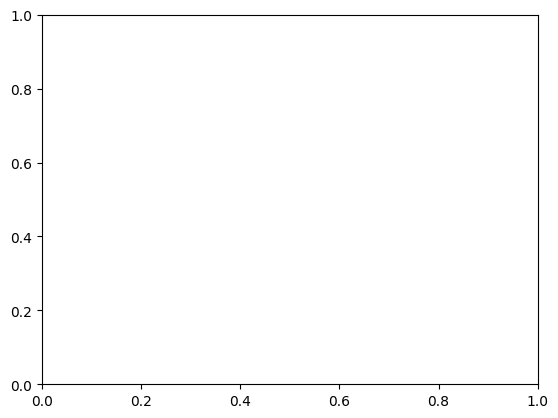

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, figsize= (16, 8), dpi=150)

sns.heatmap(df_with_target.corr(), annot=True)